# tinylm pretrain — analysis

Analysis-only notebook: loads the checkpoint produced by `train.py` (never trains).

- model: `model.py` (~6M GPT: RoPE + QK-norm + ReLU² MLP, FlexAttention doc masking)
- training: `train.py` (raw PyTorch loop; saves to `/mnt/ai/runs/tinylm/pretrain/`)
- results tables: `README.md`

In [1]:
import os

os.environ.setdefault("HF_HOME", "/mnt/ai/data/hf")  # datasets cache
# The current checkpoints (tok16k_4b + the context stages) were all trained with
# the PINNED 16k tokenizer, not a per-run vocab trained on the mixture. Pin it
# here BEFORE importing train so dm.tokenizer matches the checkpoint — otherwise
# make_datamodule() trains a fresh vocab, the prompt is encoded and the model's
# output decoded with the WRONG ids, and generations come out garbled ("weird").
os.environ["TINYLM_TOKENIZER_PATH"] = (
    "/root/Code/chimera/projects/tinylm/data/tokenizers/16k/tokenizer.json"
)

import matplotlib.pyplot as plt
import torch

import train  # project config: model/data/loss definitions (no training on import)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE in ("cuda",) else torch.float32

In [4]:
dm = train.make_datamodule()

# train_tokens = len(dm.train_dataset.data)
# val_tokens = len(dm.val_dataset.data)

# print(f"vocab_size={dm.vocab_size}")
# print(
#     "train mix: "
#     + "  ".join(
#         f"{k}={v:,} ({v / train_tokens:.0%})" for k, v in dm.source_train_tokens.items()
#     )
# )
# print(
#     f"train tokens={train_tokens:,}  val tokens={val_tokens:,}  "
#     f"total={train_tokens + val_tokens:,}"
# )

train mix: tiny-textbooks=0 (0%)  cosmopedia-v2=180,000,000 (30%)  fineweb-edu=204,000,000 (34%)  tinystories-v2=180,000,000 (30%)  tiny-webtext=0 (0%)  gooaq=30,000,000 (5%)  squad=6,000,000 (1%)


Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Tokenizing cosmopedia-v2 [train]:   0%|          | 0/745052 [00:00<?, ?doc/s]

Tokenizing fineweb-edu [train]:   0%|          | 0/718740 [00:00<?, ?doc/s]

Tokenizing tinystories-v2 [train]:   0%|          | 0/2717694 [00:00<?, ?story/s]

Tokenizing gooaq [train]:   0%|          | 0/1491186 [00:00<?, ?pair/s]

Tokenizing squad [train]:   0%|          | 0/87599 [00:00<?, ?passage/s]

In [5]:
from pathlib import Path

# Pick which checkpoint to analyze (base 512, or a context stage).
train.CHECKPOINT_PATH = Path("/mnt/ai/runs/tinylm/pretrain/chimera_gpt6m_ctx8k.pt")
assert train.CHECKPOINT_PATH.exists(), (
    f"run train.py first: {train.CHECKPOINT_PATH} missing"
)

state = torch.load(train.CHECKPOINT_PATH, map_location="cpu")
# older checkpoints were saved from the torch.compile wrapper -> _orig_mod. prefixes
state = {k.removeprefix("_orig_mod."): v for k, v in state.items()}

# Match the model to the checkpoint's architecture. Plain-baseline runs (VWN off)
# have no virtual-width expansion -> no input_expand/output_reduce and 1x1 routing
# params; VWN(2,3) runs do. Building with the wrong VWN config fails load_state_dict,
# so infer it from the state dict rather than trusting the module default.
_plain = "input_expand.weight" not in state
train.VWN_M, train.VWN_N = (1, 1) if _plain else (2, 3)

model = train.make_model(dm.vocab_size, 8192)
model.load_state_dict(state)
model.to(
    DEVICE, dtype=DTYPE
).eval()  # move explicitly — inference on CPU is ~30x slower

total_params = sum(p.numel() for p in model.parameters())
print(
    f"loaded {train.CHECKPOINT_PATH}  (VWN={train.VWN_M},{train.VWN_N}, "
    f"{total_params:,} params, device={DEVICE})"
)

loaded /mnt/ai/runs/tinylm/pretrain/chimera_gpt6m_ctx8k.pt  (VWN=1,1, 15,167,304 params, device=cuda)


## Attention masking

Training uses FlexAttention with a causal + document block mask and per-document RoPE
positions (`chimera.models.attention.build_block_mask_and_pos`). The dense reference
masks below are the readable spec of the same rule.

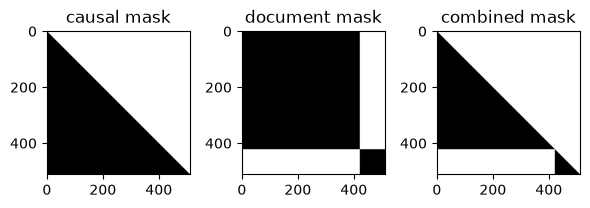

In [6]:
from chimera.models.attention import make_causal_mask, make_document_mask

x, y = next(iter(dm.train_dataloader()))

causal = make_causal_mask(train.SEQ_LEN, device=x.device)  # (1, 1, T, T)
doc = make_document_mask(x, eos_id=dm.eos_id)  # (B, 1, T, T)
attn_mask = causal & doc  # (B, 1, T, T), broadcasts fine

plt.figure(figsize=(6, 6))
plt.subplot(1, 3, 1)
plt.imshow(causal[0, 0].cpu(), cmap="gray_r")
plt.title("causal mask")
plt.subplot(1, 3, 2)
plt.imshow(doc[0, 0].cpu(), cmap="gray_r")
plt.title("document mask")
plt.subplot(1, 3, 3)
plt.imshow(attn_mask[0, 0].cpu(), cmap="gray_r")
plt.title("combined mask")
plt.tight_layout()
plt.show()

## Samples

In [12]:
from textwrap import fill

print(
    fill(
        model.sample(
            dm.tokenizer,
            prompt="Once upon a time",
            eos_token_id=dm.eos_id,
            bos_token_id=dm.bos_id,
            seed=42,
            max_new_tokens=2048,
        )  # type: ignore
    )
)

Once upon a time, there was an elderly man named Tom. He had a big box
of toys and many things to do with his dog, Max. Tom liked to play
with the toys all day long. One day, Tom went for a walk in the park.
He saw a little boy who lived next door. The boy said, "Hi, I am Tim."
Tom gave the boy a piece of toy to play with. Tim looked at the toy
and smiled. After playing, Tim asked, "Can I play with you?" Tom said,
"Yes, but be careful!" Tim took the toy to Max's house. They played
together, and Tom was happy.


In [25]:
print(
    model.sample(
        dm.tokenizer,
        prompt="""Lesson: How to Write an Obituary

Introduction:
An obituary is a written notice of a person's death, typically found in newspapers or online publications. Writing an obituary can be a difficult task, especially when you are grieving the loss of a loved one. However, it is an important task that helps to honor the life of the deceased and inform others of their passing. In this lesson, we will learn how to write an obituary by examining the structure, content, and tone of a sample obituary.

Section 1: Structure of an Obituary

An obituary typically follows a standard structure that includes the following components:""",
        eos_token_id=dm.eos_id,
        bos_token_id=dm.bos_id,
        max_new_tokens=512,
    ),  # type: ignore
)

Lesson: How to Write an Obituary

Introduction:
An obituary is a written notice of a person's death, typically found in newspapers or online publications. Writing an obituary can be a difficult task, especially when you are grieving the loss of a loved one. However, it is an important task that helps to honor the life of the deceased and inform others of their passing. In this lesson, we will learn how to write an obituary by examining the structure, content, and tone of a sample obituary.

Section 1: Structure of an Obituary

An obituary typically follows a standard structure that includes the following components:

 A1a = 5 - 8 - 7 - 9 - 10 - 18 - 1 - 19 - 19th century
b1c2a3(d)a2da3e2da4da3di1ba3da2e3da3di1a0Da1a2dtuhkyanineh2da5Kwai-AH2OGYZHQLYS-WORLDUXEJARNCE, Hagi Maurice, Gentleman Jaha'ohawidyhaqfihaquahadh, Ejithi Yabhi (Chilezhqfihiqvāma), Jajnapah Ḥūtārī, Rashian Kafari Nihilim, Sashhen Nihilim Shapirokara, Pairai Ahmadiram, Pairai Nihilim Bayaratan, Washhen Nihilim Bishikur

## Zero-shot benchmarks (`lm_eval`)

Zero-shot capability benchmarks via EleutherAI's `lm_eval`. All five are
**loglikelihood-ranking** tasks (score candidate continuations, pick the highest logprob), so we
only expose the model through `lm_eval`'s loglikelihood interface — no generation needed.

Headline metric per task (preference `acc_norm > acc > perplexity`):

| task             | metric              | chance | category             | what it tests                                                                                                                 |
|------------------|---------------------|--------|----------------------|-------------------------------------------------------------------------------------------------------------------------------|
| `blimp`          | `acc`               | 50.0   | short-range grammar  | Two sentences differ by one grammatical feature (agreement, negative polarity, islands); model must favor the grammatical one |
| `lambada_openai` | `acc`, `perplexity` | 0.0    | long-range coherence | Predict the final word of a passage, guessable only from broad discourse context, not local syntax                            |
| `piqa`           | `acc_norm`          | 50.0   | physical commonsense | Given a goal, pick which of two proposed actions actually works physically                                                    |
| `sciq`           | `acc_norm`          | 25.0   | science fact recall  | 4-way multiple choice, elementary/middle-school science questions (physics, chem, bio)                                        |
| `arc_easy`       | `acc_norm`          | 25.0   | science reasoning    | 4-way multiple choice, grade-school science QA (easier split of ARC)                                                          |

At ~2M params / 1000 steps expect everything at/near chance except possibly `blimp` (linguistic
competence, not knowledge — the BabyLM yardstick that moves first). Logged so the trend is visible
as the model scales.

In [9]:
from chimera.evals import ChimeraLM, TASKS, results_table, run_eval

lm = ChimeraLM(
    model,
    dm.tokenizer,
    eot_id=dm.eos_id,
    bos_id=dm.bos_id,
    block_size=model.seq_len,
    device=DEVICE,
    batch_tokens=131072,  # tiny model -> pack big batches for fewer kernel launches
)
results = run_eval(lm, TASKS)
display(results_table(results, TASKS))

[bench] loaded pretokenized eval inputs from chimera-tokcache-a4b5d036f29b6dacbfcf841776cbcc64.pkl


loglikelihood: 100%|██████████| 156330/156330 [00:24<00:00, 6391.11it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:08<00:00, 12.44it/s]


,metric,this model,stderr,chance,GPT-2 small (124M)
task,,,,,
blimp,acc,54.45,0.18,50.0,82.29
lambada_openai,acc,1.26,0.16,0.0,32.16
piqa,acc_norm,49.67,1.17,50.0,62.62
sciq,acc_norm,43.60,1.57,25.0,64.40
arc_easy,acc_norm,26.43,0.90,25.0,39.52


Past results (data-mix ablations at 1k iters) live in the [README](README.md).

## Train-step profile

Times the optimized train path (FlexAttention + torch.compile + CCE) on an isolated
copy of the model — never mutates the loaded weights.

In [13]:
from chimera.utils import profile_train_step

profile_train_step(
    model,
    next(iter(dm.train_dataloader())),
    loss_fn=lambda m, bx, by: train.compute_loss(m, bx, by, dm.eos_id, dm.vocab_size),
    make_optimizer=train.make_optimizer,
    loss_label="CutCrossEntropy" if train.USE_CCE else "CrossEntropyLoss",
)

batch (128, 512)  (65,536 tokens)  |  loss: CutCrossEntropy  |  20 iters
------------------------------------------------------------
forward      35.102 ms  (30.9%)
backward     74.912 ms  (65.9%)
optimizer     3.700 ms  ( 3.3%)
------------------------------------------------------------
step total  113.714 ms   ->  576,321 tokens/s
peak memory 5.56 GB


/root/Code/chimera/.venv/lib/python3.13/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-07-19 03:57:27 2900839:2900839 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-19 03:57:27 2900839:2900839 ActivityProfilerController.cpp:455] profiler_stop



-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         1.11%       6.055ms         1.53%       8.372ms      23.255us     194.371ms        36.04%     194.371ms     539.920us           360  
                     LinearCrossEntropyFunctionBackward         0.23%       1.260ms         1.10%       6.042ms       1.208ms     112.895ms        20.93%     113.302ms      22.660ms             5  
        